<a href="https://colab.research.google.com/github/HARSITHRAM/Interactive-Online-Class/blob/main/int_class03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install paho-mqtt deepface
!wget https://github.com/googlefonts/roboto/raw/main/src/hinted/Roboto-Bold.ttf -O /content/bold.ttf
!apt-get update
!apt-get install -y libfreetype6-dev libpng-dev
!pip install -U Pillow

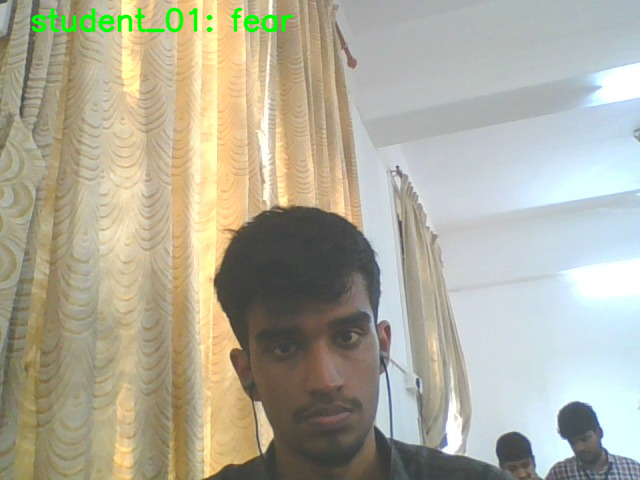

📡 Sending: student_01 is not active
🛑 Stopped by user
✅ Session ended.


In [6]:
# === IMPORTS ===
from google.colab.patches import cv2_imshow
from IPython.display import display, clear_output, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from deepface import DeepFace
from PIL import Image
import time
import paho.mqtt.client as mqtt
import socket
import re
import threading

# === SETTINGS ===
broker = "b7567dff6628421e8bfca997634b396b.s1.eu.hivemq.cloud"
port = 8883
username = "HARSITHRAM"
password = "Ram@2005"
topic_sub = "teacher_input"
topic_pub = "student_status"

# === GLOBAL FLAG ===
student_to_check = None
last_processed = ""

# === FUNCTIONS ===
def js_to_image(js_reply):
    image_bytes = b64decode(js_reply.split(',')[1])
    jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
    img = cv2.imdecode(jpg_as_np, flags=1)
    return img

def video_frame():
    js_code = '''
        async function capture() {
            const video = document.createElement('video');
            const canvas = document.createElement('canvas');
            const ctx = canvas.getContext('2d');
            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            await video.play();
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            ctx.drawImage(video, 0, 0, canvas.width, canvas.height);
            const img = canvas.toDataURL('image/jpeg');
            stream.getTracks().forEach(track => track.stop());
            return img;
        }
        capture();
    '''
    return eval_js(js_code)

def overlay_emotion_text(frame, text, position=(30, 30), font_scale=1, thickness=2):
    cv2.putText(frame, text, position, cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 255, 0), thickness, cv2.LINE_AA)

def extract_student_name(message):
    match = re.search(r'\b([a-zA-Z_0-9]+)\b', message.lower())
    return match.group(1) if match else None

# === MQTT CALLBACKS ===
def on_connect(client, userdata, flags, rc):
    print(f"✅ Connected with result code {rc}")
    client.subscribe(topic_sub)

def on_message(client, userdata, msg):
    global student_to_check, last_processed
    message = msg.payload.decode()
    print(f"\n📩 Received message from teacher: {message}")

    name = extract_student_name(message)
    if name and name != last_processed:
        student_to_check = name
        last_processed = name
    else:
        print("ℹ️ No new student name found.")

# === MQTT SETUP ===
client = mqtt.Client(client_id="colab_emotion", protocol=mqtt.MQTTv311)
client.tls_set()
client.username_pw_set(username, password)
client.on_connect = on_connect
client.on_message = on_message

try:
    client.connect(broker, port)
    client.loop_start()
except Exception as e:
    print("❌ MQTT connection failed:", e)

# === MAIN LOOP ===
try:
    while True:
        if student_to_check:
            print(f"🧠 Checking: {student_to_check}")

            js_img = video_frame()
            if not js_img:
                print("❌ Could not capture image.")
                continue

            frame = js_to_image(js_img)

            try:
                result = DeepFace.analyze(img_path=frame, actions=['emotion'], enforce_detection=False)
                emotion = result[0]['dominant_emotion']
                print(f"🎯 Emotion detected: {emotion}")
            except Exception as e:
                print("❌ Emotion analysis error:", e)
                continue

            # Overlay text
            overlay_emotion_text(frame, f"{student_to_check}: {emotion}")
            clear_output(wait=True)
            display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

            # Determine status
            attentive = ['happy', 'neutral']
            inattentive = ['sad', 'surprise', 'fear']

            if emotion in attentive:
                msg = f"{student_to_check} is active"
            elif emotion in inattentive:
                msg = f"{student_to_check} is not active"
            else:
                msg = f"{student_to_check} status unknown"

            print(f"📤 Publishing: {msg}")
            client.publish(topic_pub, msg)

            # Reset check
            student_to_check = None

        time.sleep(1)

except KeyboardInterrupt:
    print("🛑 Interrupted by user.")

finally:
    client.loop_stop()
    client.disconnect()
    print("✅ Disconnected and finished.")
